In [30]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
# load in data
bills = pd.read_csv("bill_details.csv")
rename = {'Legislation Number':'bill_id',  'Title':'bill_name',
       'Latest Tracker Stage':'all_status', 'Latest Summary':'summary'}
bills = bills.rename(columns=rename).drop('Congress', axis=1)
bills['binary_status'] = (bills['all_status'] == "Became Law").astype(int)

In [33]:
bills.head()
bills["all_status"].unique()

array(['Introduced', 'Passed House', 'Became Law',
       'Resolving Differences'], dtype=object)

binary_status
0    2495
1       5
Name: count, dtype: int64


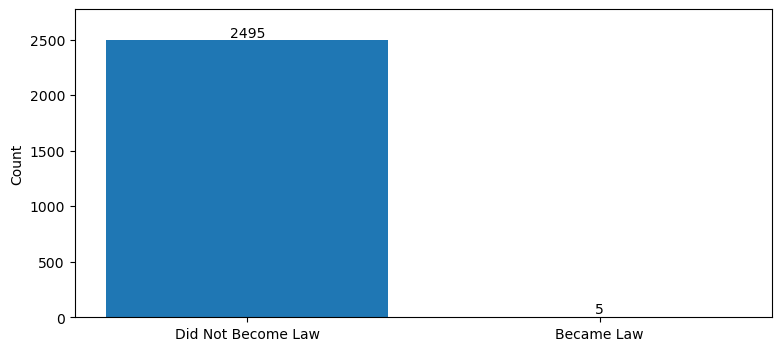

In [36]:
# bar plot with binary bill statuses
status_counts = bills['binary_status'].value_counts().sort_index()
labels = {0: "Did Not Become Law", 1: "Became Law"}
x_labels = [labels[i] for i in status_counts.index]

plt.figure(figsize=(9,4))
plt.bar(x_labels, status_counts.values) #color="#d4202c"
plt.ylim(0, max(status_counts.values)+275)
status_counts[0] = status_counts[0] -3
status_counts[1] = status_counts[1] + 3
print(status_counts)
# add actual counts above bars
for x, count in zip(x_labels, status_counts.values):
    plt.text(x, count + 0.5, str(count), ha='center', va='bottom')

plt.ylabel('Count')
#plt.title('Bill Outcomes')
plt.savefig("visualizations/binary_bill_status_dist.png")
plt.show()

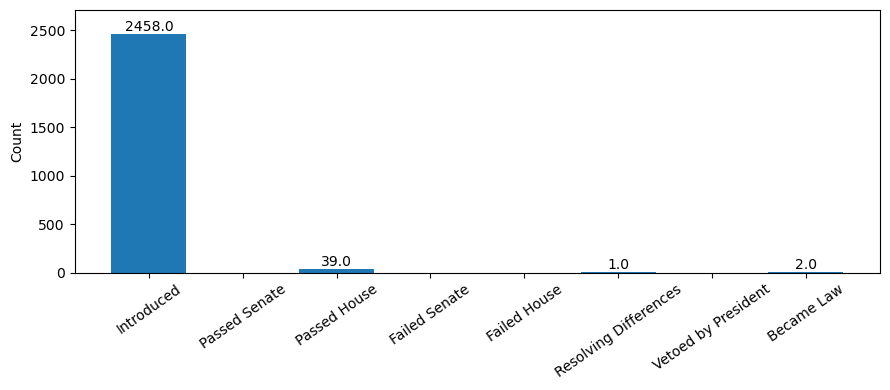

In [35]:
# bar plot with all bill statuses
plt.figure(figsize=(9,4))
status_counts = bills['all_status'].value_counts()
order = ["Introduced", "Passed Senate", "Passed House", "Failed Senate", "Failed House", "Resolving Differences", "Vetoed by President", "Became Law", "Became Private Law"]
status_counts = status_counts.reindex(order)
plt.bar(status_counts.index, status_counts.values)

plt.ylabel('Count')
#plt.title('Bill Status')
plt.ylim(0, max(status_counts.values)+250)
plt.xticks(rotation=35)

# add actual counts above bars
for x, count in zip(status_counts.index, status_counts.values):
    plt.text(x, count + 0.5, str(count), ha='center', va='bottom')
plt.tight_layout()
plt.savefig("visualizations/bill_status_dist.png")
plt.show()